<a href="https://colab.research.google.com/github/olgasherbiena/KPI/blob/main/%D0%90%D0%9A%D0%9C%D0%9C%D0%9D_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Добро пожаловать в Colab!

In [ ]:
!wget http://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip

--2026-05-12 13:44:49--  http://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip
Resolving press.liacs.nl (press.liacs.nl)... 132.229.137.37
Connecting to press.liacs.nl (press.liacs.nl)|132.229.137.37|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip [following]
--2026-05-12 13:44:49--  https://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip
Connecting to press.liacs.nl (press.liacs.nl)|132.229.137.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3069184257 (2.9G) [application/zip]
Saving to: ‘mirflickr25k.zip’

mirflickr25k.zip    100%[===================>]   2.86G  14.5MB/s    in 3m 59s  

2026-05-12 13:48:49 (12.3 MB/s) - ‘mirflickr25k.zip’ saved [3069184257/3069184257]



In [ ]:
!unzip -q mirflickr25k.zip

In [ ]:
import os, random, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter

# Налаштування
base_path = "/content/mirflickr"
student_id = 12
random.seed(student_id)

# Вибірка (Пункт 1)
all_indices = list(range(1, 20001))
sample_indices = random.sample(all_indices, 250)

print(f"✅ Сформовано вибірку з {len(sample_indices)} зображень.")
print(f"Перші 5 індексів: {sample_indices[:5]}")

✅ Сформовано вибірку з 250 зображень.
Перші 5 індексів: [15551, 8815, 17339, 11462, 4673]


Середнє (Mean): Це математичне сподівання. Для пікселів (0–255) воно показує загальну яскравість каналу.

Дисперсія (Var): Другий центральний момент. Показує розкид кольорів (контрастність)

Асиметрія (Skew): Третій центральний момент. Від'ємна.
Від'ємна асиметрія означає, що лівий хвіст розподілу довший, а більша частина значень (маса) зосереджена праворуч, тобто у світлих тонах

Ексцес (Kurtosis): Четвертий центральний момент.
Це платикуртичний розподіл — він більш плоский, ніж нормальний, з менш вираженим піком

In [ ]:
all_stats = []
best_fits = []
dist_models = {
    'norm': stats.norm,
    'laplace': stats.laplace,
    'expon': stats.expon,
    'uniform': stats.uniform,
    'gamma': stats.gamma
}

print("Обробка розпочата ...")

for i, idx in enumerate(sample_indices):
    img = cv2.imread(os.path.join(base_path, f"im{idx}.jpg"))
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if (i + 1) % 50 == 0:
        print(f"📊 Опрацьовано {i + 1}/250 зображень")

    for j, col_name in enumerate(['Red', 'Green', 'Blue']):
        data = img_rgb[:, :, j].flatten()

        # Характеристики
        q1, q3 = np.percentile(data, [25, 75])
        all_stats.append({
            'Image_ID': idx, 'Channel': col_name,
            'Min': np.min(data), 'Max': np.max(data),
            'Mean': np.mean(data), 'Var': np.var(data),
            'Median': np.median(data), 'IQR': q3 - q1,
            'Skew': stats.skew(data), 'Kurtosis': stats.kurtosis(data)
        })

        # Апроксимація
        sample_data = data[::50] # децимація (крок) для прискорення обчислень
        y, x = np.histogram(sample_data, bins=30, density=True)
        x_mid = (x[:-1] + x[1:]) / 2

        best_sse = float('inf')
        best_name = 'norm'
        for name, dist in dist_models.items():
            try:
                p = dist.fit(sample_data)
                sse = np.sum((y - dist.pdf(x_mid, *p))**2)
                if sse < best_sse:
                    best_sse, best_name = sse, name
            except: continue
        best_fits.append(best_name)

print("✅ Розрахунки завершено!")

Обробка розпочата ...
📊 Опрацьовано 50/250 зображень
📊 Опрацьовано 100/250 зображень
📊 Опрацьовано 150/250 зображень
📊 Опрацьовано 200/250 зображень
📊 Опрацьовано 250/250 зображень
✅ Розрахунки завершено!


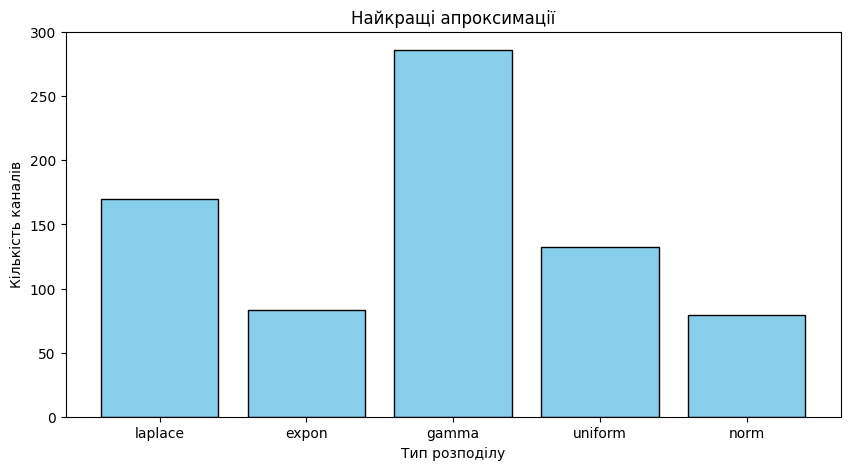


📝 Фрагмент розрахованих характеристик (Пункт 2):
 Image_ID Channel  Min  Max       Mean         Var  Median   IQR      Skew  Kurtosis
    15551     Red    0  255 129.613152 2989.883202   151.0  87.0 -0.755951 -0.675102
    15551   Green    0  255 144.694613 3907.430942   178.0 101.0 -0.795859 -0.836761
    15551    Blue    0  255 149.596480 5682.138132   181.0 136.0 -0.605763 -1.191384


In [ ]:
df = pd.DataFrame(all_stats)
df.to_csv('statistical_results.csv', index=False)

# Візуалізація (Пункт 5)
plt.figure(figsize=(10, 5))
counts = Counter(best_fits)
plt.bar(counts.keys(), counts.values(), color='skyblue', edgecolor='black')
plt.title(f"Найкращі апроксимації")
plt.xlabel("Тип розподілу")
plt.ylabel("Кількість каналів")
plt.show()

print("\n📝 Фрагмент розрахованих характеристик (Пункт 2):")
print(df.head(3).to_string(index=False))